In [7]:
import json 
import numpy as np 
import scipy.stats as stats 
import matplotlib.pyplot as plt 


# index 0 -> 7, index, index 1 ->2, index 2 ->1 , index 3 -> 0 , index 4 -> 4 , index 7 -> 9
# index 11 -> 6, index 15 -> 5, index 18 -> 8, last_index -> 3 
correct_vector = [7,2,1,0,4,9,6,5,8,3]

def calculate_validation_rate(predicted_y: list[np.ndarray],
                              y: list[np.ndarray]) -> float | int:
    """
    Calculate the validation rate (accuracy) for predicted and actual labels.

    Parameters:
    - predicted_y: array-like, predicted probabilities or logits (e.g., from a neural network).
    - y: array-like, one-hot encoded true labels.

    Returns:
    - float, the accuracy rate as the proportion of correctly predicted samples.
    """
    predicted_indices = np.array(list(map(np.argmax, predicted_y)))
    true_indices = np.array(list(map(np.argmax, y)))
    accuracy = np.mean(predicted_indices == true_indices)
    return accuracy

def mode_of_argmaxes(list_of_lists: list[list[list[float]]]) -> list[int]:
    """
    For each sub‐list `l` in `list_of_lists`:
      1. Compute argmax of each inner list `l'`.
      2. Take the statistical mode of those argmaxes.
    Returns a list of one mode‐index per `l`.
    """
    modes = []
    for l in list_of_lists:
        # 1) argmax of each l'
        argmaxes = [int(np.argmax(l_prime)) for l_prime in l]
        # 2) most common
        mode_idx = int(stats.mode(argmaxes)[0])
        modes.append(mode_idx)
    return modes


In [28]:
FILE_DIR= "/Users/dlakhdar/physics/repos/natural-quantization/data/quantum_nn_rotation_angles/experiment_data/"

with open(FILE_DIR + "results1.json",'r') as f : 
    result1 = json.load(f)

with open(FILE_DIR + "results2.json",'r') as f : 
    result2 = json.load(f)



data = result1 + result2


In [37]:
correct_vector = [7,2,1,0,4,9,6,5,8,3]


In [30]:
from collections import defaultdict

def merge_for_as(data, a_values):
    # 1) Group all 3rd‑elements by their a
    groups = defaultdict(list)
    for a, _, lists in data:
        if a in a_values:
            groups[a].extend(lists)

    # 2) Build the result list in the order of a_values
    return [[a, groups[a]] for a in a_values]

new_data = merge_for_as(data,As)

In [46]:
As = [0.0,.1,.2,.5,1.0]
data[0]

modes = []
for a,d in new_data: 
    results = d
    modes.append((a,stats.mode(results,axis=1).mode))


validation_rates = [ ]
for i,m in modes:
    print(i, np.mean(m == np.array(correct_vector)))
    validation_rates.append(np.mean(m == np.array(correct_vector)))


0.0 0.9
0.1 0.8
0.2 0.9
0.5 0.9
1.0 0.9


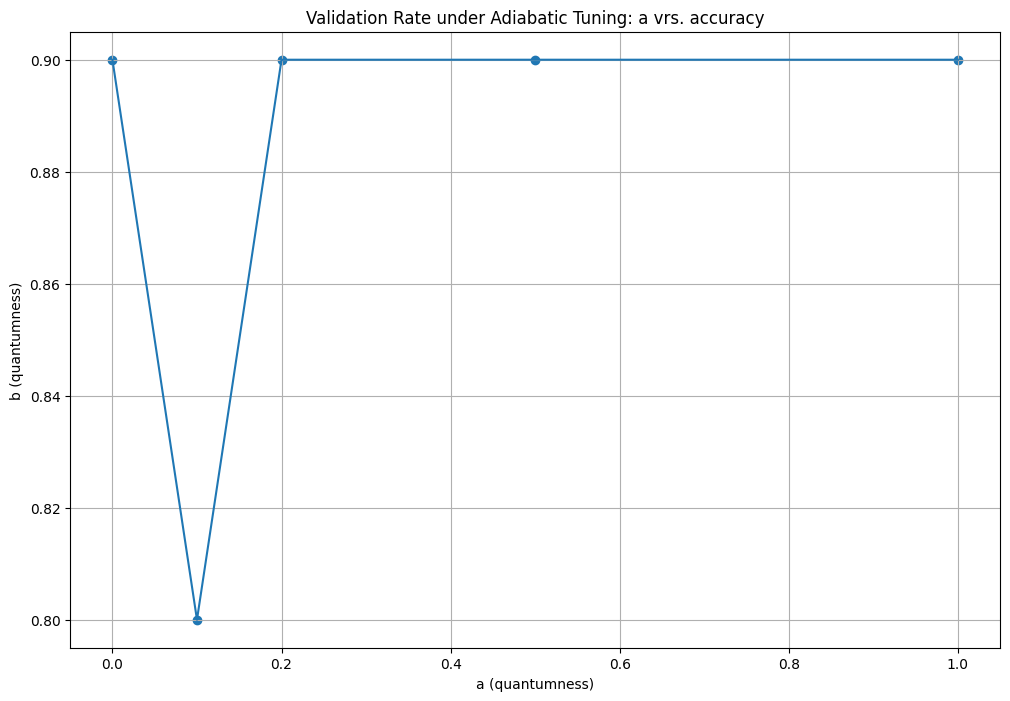

In [53]:
plt.figure(figsize=(12,8))
plt.scatter(As,validation_rates)
plt.plot(As,validation_rates)
plt.title("Validation Rate under Adiabatic Tuning:")
plt.xlabel("a (quantumness)")
plt.ylabel("b (quantumness)")
plt.grid()

In [48]:
correct_vector

[7, 2, 1, 0, 4, 9, 6, 5, 8, 3]

In [1]:
import numpy as np 
from numpy import array as array 

results = [[0.5, 16, [[array([3, 3, 1, 5, 4, 9]), array([7, 2, 1, 5, 4, 9]), array([7, 2, 1, 0, 4, 9]), array([7, 0, 1, 9, 4, 9]), array([7, 2, 1, 0, 4, 9])], [array([3, 3, 1, 5, 4, 9]), array([7, 2, 1, 5, 4, 9]), array([7, 2, 1, 0, 4, 9]), array([7, 0, 1, 9, 4, 9]), array([7, 2, 1, 0, 4, 9])], [array([3, 3, 1, 5, 4, 9]), array([7, 2, 1, 5, 4, 9]), array([7, 2, 1, 0, 4, 9]), array([7, 0, 1, 9, 4, 9]), array([7, 2, 1, 0, 4, 9])], [array([3, 3, 1, 5, 4, 9]), array([7, 2, 1, 5, 4, 9]), array([7, 2, 1, 0, 4, 9]), array([7, 0, 1, 9, 4, 9]), array([7, 2, 1, 0, 4, 9])], [array([3, 3, 1, 5, 4, 9]), array([7, 2, 1, 5, 4, 9]), array([7, 2, 1, 0, 4, 9]), array([7, 0, 1, 9, 4, 9]), array([7, 2, 1, 0, 4, 9])], [array([6, 8, 8, 3, 0, 2]), array([6, 5, 1, 3, 7, 2]), array([2, 8, 8, 3, 7, 2]), array([6, 5, 8, 3, 7, 2]), array([7, 5, 3, 5, 7, 2])], [array([6, 8, 8, 3, 0, 2]), array([6, 5, 1, 3, 7, 2]), array([2, 8, 8, 3, 7, 2]), array([6, 5, 8, 3, 7, 2]), array([7, 5, 3, 5, 7, 2])], [array([6, 8, 8, 3, 0, 2]), array([6, 5, 1, 3, 7, 2]), array([2, 8, 8, 3, 7, 2]), array([6, 5, 8, 3, 7, 2]), array([7, 5, 3, 5, 7, 2])], [array([6, 8, 8, 3, 0, 2]), array([6, 5, 1, 3, 7, 2]), array([2, 8, 8, 3, 7, 2]), array([6, 5, 8, 3, 7, 2]), array([7, 5, 3, 5, 7, 2])], [array([6, 8, 8, 3, 0, 2]), array([6, 5, 1, 3, 7, 2]), array([2, 8, 8, 3, 7, 2]), array([6, 5, 8, 3, 7, 2]), array([7, 5, 3, 5, 7, 2])]]]]


In [6]:
results[0][2]

[[array([3, 3, 1, 5, 4, 9]),
  array([7, 2, 1, 5, 4, 9]),
  array([7, 2, 1, 0, 4, 9]),
  array([7, 0, 1, 9, 4, 9]),
  array([7, 2, 1, 0, 4, 9])],
 [array([3, 3, 1, 5, 4, 9]),
  array([7, 2, 1, 5, 4, 9]),
  array([7, 2, 1, 0, 4, 9]),
  array([7, 0, 1, 9, 4, 9]),
  array([7, 2, 1, 0, 4, 9])],
 [array([3, 3, 1, 5, 4, 9]),
  array([7, 2, 1, 5, 4, 9]),
  array([7, 2, 1, 0, 4, 9]),
  array([7, 0, 1, 9, 4, 9]),
  array([7, 2, 1, 0, 4, 9])],
 [array([3, 3, 1, 5, 4, 9]),
  array([7, 2, 1, 5, 4, 9]),
  array([7, 2, 1, 0, 4, 9]),
  array([7, 0, 1, 9, 4, 9]),
  array([7, 2, 1, 0, 4, 9])],
 [array([3, 3, 1, 5, 4, 9]),
  array([7, 2, 1, 5, 4, 9]),
  array([7, 2, 1, 0, 4, 9]),
  array([7, 0, 1, 9, 4, 9]),
  array([7, 2, 1, 0, 4, 9])],
 [array([6, 8, 8, 3, 0, 2]),
  array([6, 5, 1, 3, 7, 2]),
  array([2, 8, 8, 3, 7, 2]),
  array([6, 5, 8, 3, 7, 2]),
  array([7, 5, 3, 5, 7, 2])],
 [array([6, 8, 8, 3, 0, 2]),
  array([6, 5, 1, 3, 7, 2]),
  array([2, 8, 8, 3, 7, 2]),
  array([6, 5, 8, 3, 7, 2]),
  array(